# Trabajo Práctico 3 - Visión por Computadora I

Detección del logo de Coca-Cola por template matching multiescala.

Resolución basada en `Codigo/Clase4/01.Templates.ipynb` (coincidencia de patrones, múltiples objetos).

In [12]:
from pathlib import Path
from typing import NamedTuple

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

BASE: Path = Path('Material_TPs/TP3')
if not BASE.exists():
    BASE = Path('.')

IMAGES_DIR: Path = BASE / 'images'
TEMPLATE_PATH: Path = BASE / 'template' / 'pattern.png'

image_filenames: list[str] = sorted(p.name for p in IMAGES_DIR.iterdir())
image_filenames

['COCA-COLA-LOGO.jpg',
 'coca_logo_1.png',
 'coca_logo_2.png',
 'coca_multi.png',
 'coca_retro_1.png',
 'coca_retro_2.png',
 'logo_1.png']

## Template

El template es el logo en rojo sobre fondo blanco. El problema es que en la mayoría de las imágenes el logo aparece con los colores invertidos (texto blanco sobre etiqueta roja: botellas, latas, el cartel circular). Si hacemos matching directo en escala de grises, un logo invertido da correlación muy negativa en vez de alta, así que se nos escapa. Solución: matchear sobre el mapa de bordes (magnitud del gradiente) en vez de sobre la intensidad.

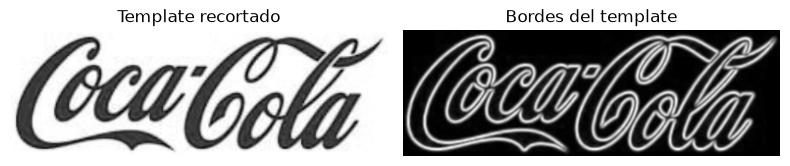

In [13]:
class Detection(NamedTuple):
    """Una detección del logo: score de confianza + caja (x, y, width, height),
    siempre en coordenadas de la imagen ORIGINAL (sin reescalar)."""
    score: float
    x: float
    y: float
    width: float
    height: float


class EdgeTemplate(NamedTuple):
    """El template ya recortado a su contenido real y convertido a mapa de bordes."""
    pixels: np.ndarray
    width: int
    height: int


def edge_magnitude(gray_image: np.ndarray) -> np.ndarray:
    """Magnitud del gradiente (Sobel), suavizada un poco para tolerar
    pequeños desajustes de escala/rotación al hacer matchTemplate."""
    blurred: np.ndarray = cv.GaussianBlur(gray_image, (3, 3), 0)
    gx: np.ndarray = cv.Sobel(blurred, cv.CV_32F, 1, 0)
    gy: np.ndarray = cv.Sobel(blurred, cv.CV_32F, 0, 1)
    magnitude: np.ndarray = cv.magnitude(gx, gy)
    return cv.GaussianBlur(magnitude, (3, 3), 0)


def read_grayscale(path: Path) -> np.ndarray:
    """Carga una imagen en escala de grises."""
    image: np.ndarray | None = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    assert image is not None, f'No se pudo cargar la imagen: {path}'
    return image


def read_image(path: Path) -> np.ndarray:
    """Carga una imagen a color (BGR)."""
    image: np.ndarray | None = cv.imread(str(path))
    assert image is not None, f'No se pudo cargar la imagen: {path}'
    return image


def crop_to_content(gray_image: np.ndarray, white_threshold: int = 240, pad: int = 5) -> np.ndarray:
    """Recorta la imagen al rectángulo que contiene sus píxeles "con tinta" (por debajo de `white_threshold`),
    con un margen `pad`. Se usa para sacarle el margen blanco al template: si lo dejamos, al reescalar el template
    a tamaños chicos terminamos comparando mucho fondo plano contra la imagen, lo que arruina la correlación."""
    content_mask: np.ndarray = gray_image < white_threshold
    ys: np.ndarray
    xs: np.ndarray
    ys, xs = np.where(content_mask)
    y0: int = max(int(ys.min()) - pad, 0)
    y1: int = int(ys.max()) + pad
    x0: int = max(int(xs.min()) - pad, 0)
    x1: int = int(xs.max()) + pad
    return gray_image[y0:y1, x0:x1]


def make_edge_template(cropped_gray: np.ndarray) -> EdgeTemplate:
    """Convierte el recorte en escala de grises en el EdgeTemplate (bordes + su tamaño) que usan las funciones de búsqueda."""
    pixels: np.ndarray = edge_magnitude(cropped_gray)
    height: int
    width: int
    height, width = pixels.shape
    return EdgeTemplate(pixels=pixels, width=width, height=height)


template_gray: np.ndarray = read_grayscale(TEMPLATE_PATH)
template_gray_cropped: np.ndarray = crop_to_content(template_gray)
template: EdgeTemplate = make_edge_template(template_gray_cropped)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(template_gray_cropped, cmap='gray')
axes[0].set_title('Template recortado')
axes[1].imshow(template.pixels, cmap='gray')
axes[1].set_title('Bordes del template')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Búsqueda multiescala (función común a los 3 ítems)

El logo aparece a tamaños muy distintos según la imagen, así que hay que probar la coincidencia con el template reescalado a muchas escalas y quedarnos con la que da mejor score. Dos detalles importantes que salieron al probar sobre las imágenes reales:

- **Ventanas "planas" dan score engañoso.** `TM_CCOEFF_NORMED` normaliza dividiendo por el desvío estándar de la ventana; sobre una zona casi sin textura (un fondo liso) esa división es casi por cero y el score puede salir artificialmente alto sin que haya ningún logo ahí. Por eso, después de cada match validamos que la ventana de la imagen tenga desvío estándar mínimo.

- **Achicar mucho el template es poco robusto.** Cuando el logo real mide pocos píxeles, reescalar el template a ese tamaño lo deja casi sin detalle y cualquier textura repetitiva (p.ej. la rosca de una tapa) puede llegar a matchear igual de bien. Por eso hacemos la búsqueda en dos etapas: una gruesa para ubicar la escala aproximada, y una fina donde en cambio agrandamos la IMAGEN (no achicamos más el template) para que la comparación se haga con un template de un tamaño razonable.

In [14]:
MIN_TEMPLATE_PX: int = 15 # por debajo de esto el template reescalado queda sin detalle confiable


class ScaleMatch(NamedTuple):
    """El mejor match encontrado a una escala dada: score, la escala en sí, su posición y tamaño (en píxeles de la imagen efectivamente buscada) y el mapa de correlación completo de esa escala (lo necesita el umbral adaptivo de detect_multiple para no tener que recalcularlo)."""
    score: float
    scale: float
    x: int
    y: int
    width: int
    height: int
    response: np.ndarray


class LocatedLogo(NamedTuple):
    """Resultado de ubicar a qué escala/resolución conviene buscar el logo en una imagen: los mapas de bordes/gris ya calculados a esa resolución, el factor de agrandado usado y el mejor match encontrado ahí."""
    edges: np.ndarray
    gray: np.ndarray
    upscale: float
    match: ScaleMatch


def bgr_to_gray(image_bgr: np.ndarray) -> np.ndarray:
    return cv.cvtColor(image_bgr, cv.COLOR_BGR2GRAY)


def scale_up(image_bgr: np.ndarray, factor: float) -> np.ndarray:
    """Agranda la imagen por `factor` (interpolación cúbica). Si el factor es ~1 devuelve la imagen tal cual,
    para no gastar tiempo de más."""
    if factor <= 1.01:
        return image_bgr
    return cv.resize(image_bgr, None, fx=factor, fy=factor, interpolation=cv.INTER_CUBIC)


def upscale_factor_for_target_width(current_width_px: float, target_width_px: float, max_factor: float = 6.0) -> float:
    """Factor para agrandar la imagen de forma que el template, que actualmente mide `current_width_px`,
    quede con un ancho de `target_width_px`. Nunca achica (mínimo 1.0) ni agranda más de `max_factor`."""
    return min(max(1.0, target_width_px / current_width_px), max_factor)


def coarse_scale_range() -> np.ndarray:
    """Rango amplio para la búsqueda gruesa: de un logo diminuto a uno 4 veces más grande que el template recortado."""
    return np.linspace(0.08, 4.0, 25)


def fine_scale_range(coarse_scale: float, upscale: float) -> np.ndarray:
    """Rango angosto (+-30%) alrededor de la escala gruesa,
    reescalado por el mismo factor de agrandado que se le aplicó a la imagen."""
    center: float = coarse_scale * upscale
    return np.linspace(center * 0.7, center * 1.3, 15)


def has_enough_texture(window: np.ndarray, min_std: float) -> bool:
    """Ver "ventanas planas dan score engañoso" en la celda de arriba."""
    return bool(window.std() >= min_std)


def find_best_scale(
    template: EdgeTemplate,
    edges_image: np.ndarray,
    gray_image: np.ndarray,
    scale_candidates: np.ndarray,
    min_std: float = 20,
) -> ScaleMatch | None:
    """Prueba el template reescalado a cada escala candidata contra `edges_image` y devuelve el mejor match global."""
    image_height: int
    image_width: int
    image_height, image_width = edges_image.shape
    best: ScaleMatch | None = None
    for scale in scale_candidates:
        width: int = int(template.width * scale)
        height: int = int(template.height * scale)
        if width < MIN_TEMPLATE_PX or height < MIN_TEMPLATE_PX or width >= image_width or height >= image_height:
            continue
        resized_template: np.ndarray = cv.resize(template.pixels, (width, height))
        response: np.ndarray = cv.matchTemplate(edges_image, resized_template, cv.TM_CCOEFF_NORMED)
        score: float
        _, score, _, loc = cv.minMaxLoc(response)
        x, y = loc

        window: np.ndarray = gray_image[y:y + height, x:x + width]
        if not has_enough_texture(window, min_std):
            continue

        if best is None or score > best.score:
            best = ScaleMatch(score, scale, x, y, width, height, response)
    return best


def locate_logo(
    template: EdgeTemplate,
    image_bgr: np.ndarray,
    min_std: float = 20,
    target_template_width_px: float = 180,
) -> LocatedLogo | None:
    """Etapa 1 (gruesa) + etapa 2 (fina, con la imagen agrandada)
    para encontrar la escala/resolución a la que mejor matchea el template."""
    gray: np.ndarray = bgr_to_gray(image_bgr)
    edges: np.ndarray = edge_magnitude(gray)
    coarse: ScaleMatch | None = find_best_scale(template, edges, gray, coarse_scale_range(), min_std)
    if coarse is None:
        return None

    upscale: float = upscale_factor_for_target_width(coarse.width, target_template_width_px)
    image_big: np.ndarray = scale_up(image_bgr, upscale)
    gray_big: np.ndarray = bgr_to_gray(image_big)
    edges_big: np.ndarray = edge_magnitude(gray_big)

    fine: ScaleMatch | None = find_best_scale(
        template, edges_big, gray_big, fine_scale_range(coarse.scale, upscale), min_std
    )
    if fine is None:
        return None
    return LocatedLogo(edges=edges_big, gray=gray_big, upscale=upscale, match=fine)

## Ítem 1 — Una detección por imagen, sin falsos positivos

Nos quedamos directamente con el máximo global de la búsqueda multiescala: no hay ningún umbral de por medio, así que no hay manera de que aparezca una detección "extra" (un falso positivo). Como mucho, la única detección que devolvemos podría estar mal ubicada, pero eso no pasó en ninguna de las imágenes (se verifica a ojo abajo).

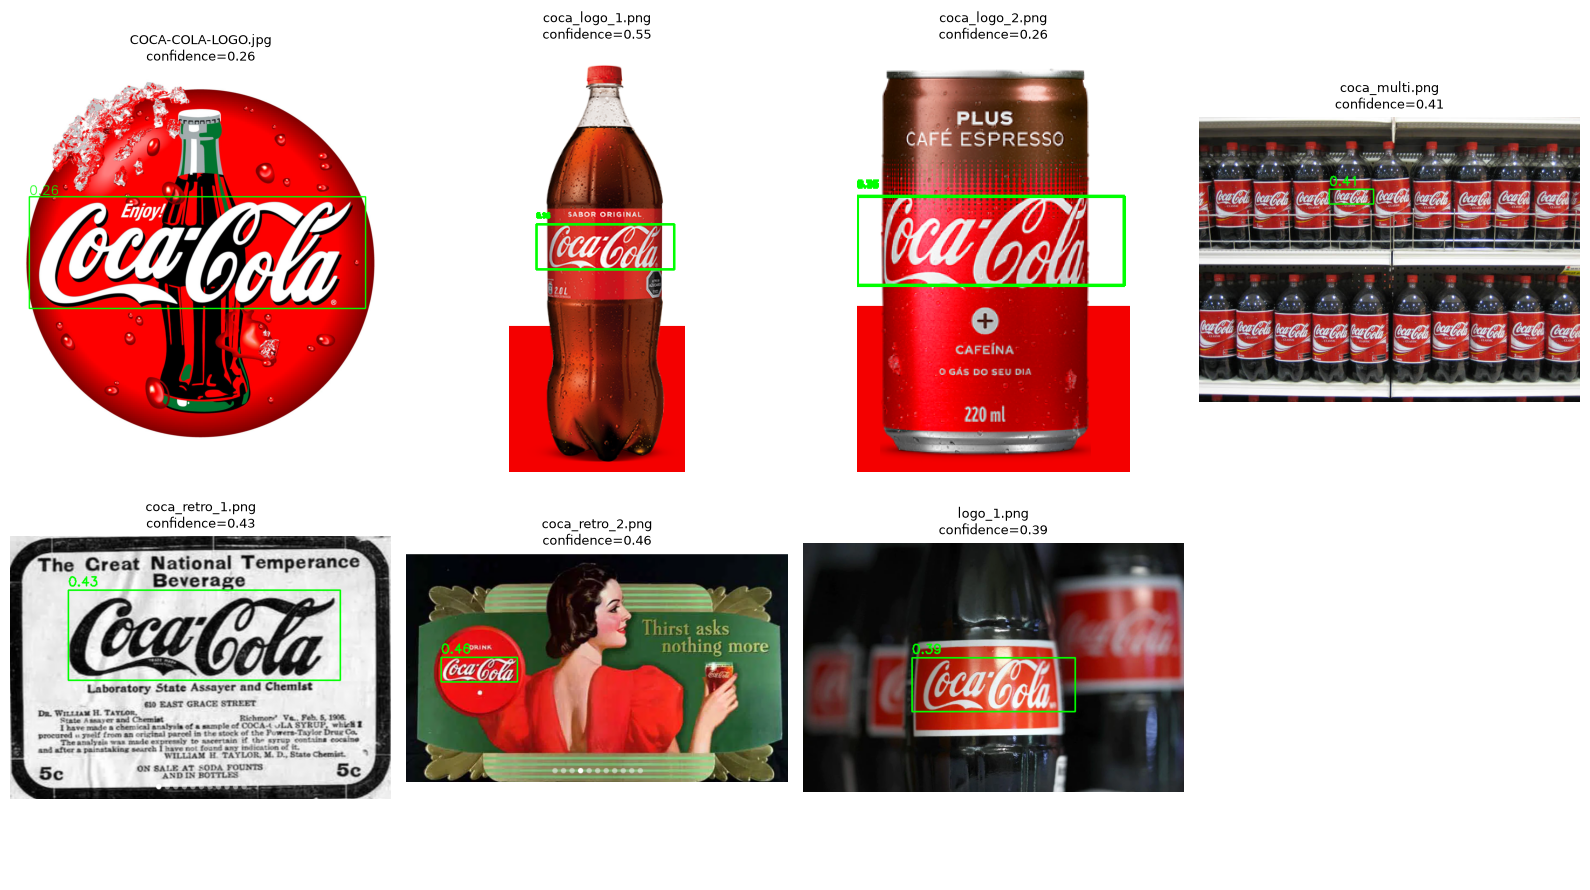

In [15]:
def to_original_scale(match: ScaleMatch, upscale: float) -> Detection:
    """Convierte un ScaleMatch (en píxeles de la imagen, potencialmente agrandada, donde se hizo la búsqueda)
    a un Detection en coordenadas de la imagen ORIGINAL."""
    return Detection(
        score=match.score,
        x=match.x / upscale,
        y=match.y / upscale,
        width=match.width / upscale,
        height=match.height / upscale,
    )


def detect_single(template: EdgeTemplate, image_bgr: np.ndarray, min_std: float = 20) -> Detection | None:
    """Ítem 1: la mejor detección global."""
    located: LocatedLogo | None = locate_logo(template, image_bgr, min_std)
    if located is None:
        return None
    return to_original_scale(located.match, located.upscale)


def draw_single_detection(
    image_bgr: np.ndarray, detection: Detection, color: tuple[int, int, int] = (0, 255, 0)
) -> np.ndarray:
    """Dibuja una única caja sobre una copia de la imagen, con el score como etiqueta."""
    output: np.ndarray = image_bgr.copy()
    x: int = int(detection.x)
    y: int = int(detection.y)
    w: int = int(detection.width)
    h: int = int(detection.height)
    thickness: int = max(2, image_bgr.shape[1] // 300)
    cv.rectangle(output, (x, y), (x + w, y + h), color, thickness)
    cv.putText(output, f'{detection.score:.2f}', (x, max(y - 8, 15)), cv.FONT_HERSHEY_SIMPLEX,
               image_bgr.shape[1] / 900, color, 2)
    return output


fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, filename in zip(axes.flat, image_filenames):
    image_bgr: np.ndarray = read_image(IMAGES_DIR / filename)
    detection: Detection | None = detect_single(template, image_bgr)
    assert detection is not None, f'No se encontró el logo en {filename}'
    output: np.ndarray = draw_single_detection(image_bgr, detection)
    ax.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
    ax.set_title(f'{filename}\nconfidence={detection.score:.2f}', fontsize=9)
    ax.axis('off')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

Las 7 detecciones caen sobre el logo real. Ningún falso positivo.

## Ítem 2 — Múltiples detecciones en `coca_multi.png`

Para encontrar todas las apariciones del logo, en vez de quedarnos con el máximo global tomamos todos los picos de correlación que superen un umbral, y después aplicamos non-maximum suppression (NMS) para colapsar cajas superpuestas que corresponden al mismo logo (igual que en
`Codigo/Clase4/01.Templates.ipynb`, pero ahí el umbral era un valor fijo elegido a mano).

Un umbral fijo no generaliza: el score del mejor match varía mucho de imagen a imagen (en `coca_multi` el mejor score es ~0.41, pero en otra imagen más ruidosa puede ser ~0.26). Entonces el umbral se arma así:

- `media(score) + k * desvío(score)` sobre el mapa de correlación: un criterio estadístico, "qué tan por encima del ruido de fondo" tiene que estar un pico para contar como detección.

- Un piso de `ratio * score_máximo`, para no terminar con un umbral más alto que el propio mejor score en imágenes donde el matching es débil en general.

- Nunca puede superar `score_máximo`: así siempre queda al menos 1 detección (la del ítem 1).

Nota sobre el piso `ratio`. Con `ratio=0.5` aparecía un falso positivo en `logo_1.png` — una caja con score 0.20 desplazada hacia arriba del logo borroso de la botella de atrás, sobre el cuello/tapa (sin texto real ahí). Es un pico de correlación débil pero genuino que superaba el piso. Subir `ratio` a 0.55 lo elimina (exige que un segundo pico esté más cerca del mejor score) sin perder ninguna detección real.

In [16]:
def non_max_suppression(
    boxes: list[tuple[float, float, float, float]],
    scores: list[float],
    iou_threshold: float = 0.2,
) -> list[int]:
    """Non-maximum suppression: entre cajas que se superponen más de `iou_threshold`, nos quedamos solo con la de mayor score.
    Devuelve los índices (sobre las listas originales) de las cajas que sobreviven."""
    if not boxes:
        return []
    boxes_arr: np.ndarray = np.array(boxes, dtype=float)
    scores_arr: np.ndarray = np.array(scores, dtype=float)
    x1: np.ndarray = boxes_arr[:, 0]
    y1: np.ndarray = boxes_arr[:, 1]
    x2: np.ndarray = x1 + boxes_arr[:, 2]
    y2: np.ndarray = y1 + boxes_arr[:, 3]
    areas: np.ndarray = boxes_arr[:, 2] * boxes_arr[:, 3]

    order: np.ndarray = np.argsort(scores_arr)[::-1]
    keep: list[int] = []
    while len(order) > 0:
        i: int = int(order[0])
        keep.append(i)
        # Intersección de la caja i con TODAS las cajas restantes a la vez (vectorizado)
        xx1: np.ndarray = np.maximum(x1[i], x1[order[1:]])
        yy1: np.ndarray = np.maximum(y1[i], y1[order[1:]])
        xx2: np.ndarray = np.minimum(x2[i], x2[order[1:]])
        yy2: np.ndarray = np.minimum(y2[i], y2[order[1:]])
        intersection: np.ndarray = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou: np.ndarray = intersection / (areas[i] + areas[order[1:]] - intersection)
        order = order[1:][iou < iou_threshold]
    return keep


def adaptive_threshold(response: np.ndarray, best_score: float, k: float = 3.5, ratio: float = 0.55) -> float:
    """Umbral para aceptar detecciones múltiples."""
    statistical: float = float(response.mean() + k * response.std())
    floor: float = ratio * best_score
    return min(best_score - 1e-6, max(statistical, floor))


def local_scale_band(center_scale: float) -> np.ndarray:
    """Rango angosto (+-15%) de escalas alrededor de la óptima:
    todas las instancias del logo en una misma imagen suelen tener un tamaño parecido
    (por ejemplo, todas las botellas de una misma góndola). Se agrega también `center_scale` exacta,
    por si el linspace no cae justo en ella (si no, podríamos perder la mejor detección de todas)."""
    candidates: np.ndarray = np.linspace(center_scale * 0.85, center_scale * 1.15, 10)
    return np.union1d(candidates, [center_scale])


def collect_candidates(
    template: EdgeTemplate,
    located: LocatedLogo,
    threshold: float,
    min_std: float = 20,
) -> tuple[list[tuple[float, float, float, float]], list[float]]:
    """Junta todas las cajas (en coordenadas de la imagen original) cuyo score supera `threshold`,
    recorriendo local_scale_band alrededor de la escala óptima ya encontrada en `located`."""
    image_height: int
    image_width: int
    image_height, image_width = located.edges.shape
    boxes: list[tuple[float, float, float, float]] = []
    scores: list[float] = []
    for scale in local_scale_band(located.match.scale):
        width: int = int(template.width * scale)
        height: int = int(template.height * scale)
        if width < MIN_TEMPLATE_PX or height < MIN_TEMPLATE_PX or width >= image_width or height >= image_height:
            continue
        resized_template: np.ndarray = cv.resize(template.pixels, (width, height))
        response: np.ndarray = cv.matchTemplate(located.edges, resized_template, cv.TM_CCOEFF_NORMED)
        rows: np.ndarray
        cols: np.ndarray
        rows, cols = np.where(response >= threshold)
        for y, x in zip(rows, cols):
            window: np.ndarray = located.gray[y:y + height, x:x + width]
            if has_enough_texture(window, min_std):
                box: tuple[float, float, float, float] = (
                    float(x) / located.upscale, float(y) / located.upscale,
                    width / located.upscale, height / located.upscale,
                )
                boxes.append(box)
                scores.append(float(response[y, x]))
    return boxes, scores


def detect_multiple(
    template: EdgeTemplate,
    image_bgr: np.ndarray,
    min_std: float = 20,
    k: float = 3.5,
    ratio: float = 0.55,
    iou_threshold: float = 0.2,
) -> list[Detection]:
    """Ítems 2 y 3: todas las detecciones del logo en `image_bgr`."""
    located: LocatedLogo | None = locate_logo(template, image_bgr, min_std)
    if located is None:
        return []
    threshold: float = adaptive_threshold(located.match.response, located.match.score, k, ratio)
    boxes: list[tuple[float, float, float, float]]
    scores: list[float]
    boxes, scores = collect_candidates(template, located, threshold, min_std)
    kept: list[int] = non_max_suppression(boxes, scores, iou_threshold)
    return [Detection(scores[i], *boxes[i]) for i in kept]

18 detecciones


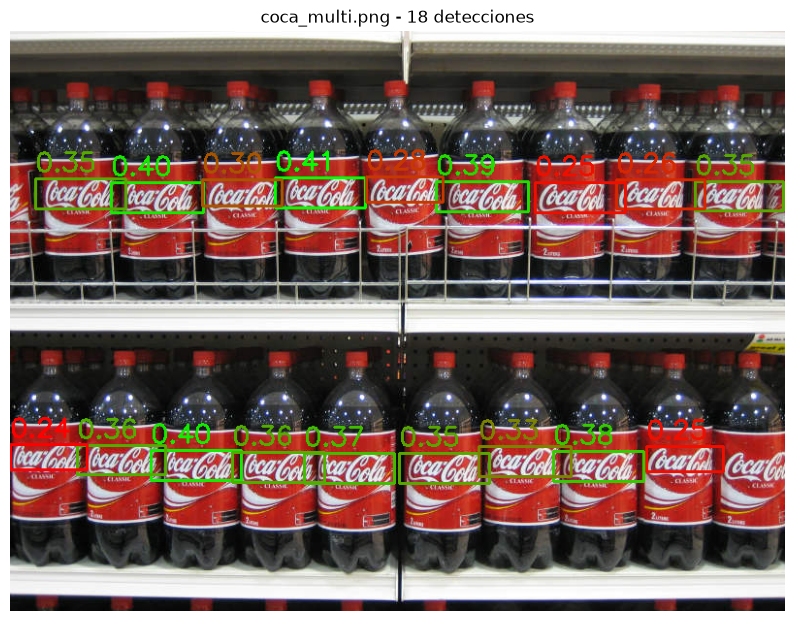

In [17]:
def confidence_color(score: float, score_min: float, score_max: float) -> tuple[int, int, int]:
    """Verde = alta confianza, rojo = confianza cerca del umbral (BGR, para cv.rectangle)."""
    t: float = 0.0 if score_max <= score_min else (score - score_min) / (score_max - score_min)
    t = float(np.clip(t, 0, 1))
    return (0, int(255 * t), int(255 * (1 - t)))


def draw_detections(image_bgr: np.ndarray, detections: list[Detection]) -> np.ndarray:
    """Dibuja todas las cajas de `detections` sobre una copia de la imagen,
    coloreadas según su confianza relativa dentro de esta misma imagen."""
    output: np.ndarray = image_bgr.copy()
    scores: list[float] = [d.score for d in detections] or [1.0]
    score_min: float = min(scores)
    score_max: float = max(scores)
    thickness: int = max(2, image_bgr.shape[1] // 300)
    for d in detections:
        x: int = int(d.x)
        y: int = int(d.y)
        w: int = int(d.width)
        h: int = int(d.height)
        color: tuple[int, int, int] = confidence_color(d.score, score_min, score_max)
        cv.rectangle(output, (x, y), (x + w, y + h), color, thickness)
        cv.putText(output, f'{d.score:.2f}', (x, max(y - 8, 15)), cv.FONT_HERSHEY_SIMPLEX,
                   image_bgr.shape[1] / 900, color, 2)
    return output


multi_image: np.ndarray = read_image(IMAGES_DIR / 'coca_multi.png')
multi_detections: list[Detection] = detect_multiple(template, multi_image)
print(f'{len(multi_detections)} detecciones')

output: np.ndarray = draw_detections(multi_image, multi_detections)
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'coca_multi.png - {len(multi_detections)} detecciones')
plt.show()

Detecta la gran mayoría de las botellas visibles, sin falsos positivos. Se pierden algunas etiquetas cortadas en el borde de la imagen o muy tapadas, donde el template ya no tiene con qué matchear.

## Ítem 3 — Generalización a todas las imágenes

`detect_multiple` no tiene nada específico de `coca_multi.png`: aplicamos la misma función, sin cambios, a las 7 imágenes. En las que tienen un único logo aparece 1 sola detección; el umbral adaptivo (con `ratio=0.55`, ver ítem 2) ya está calibrado para que un pico de correlación débil y espurio no llegue a contar como detección.

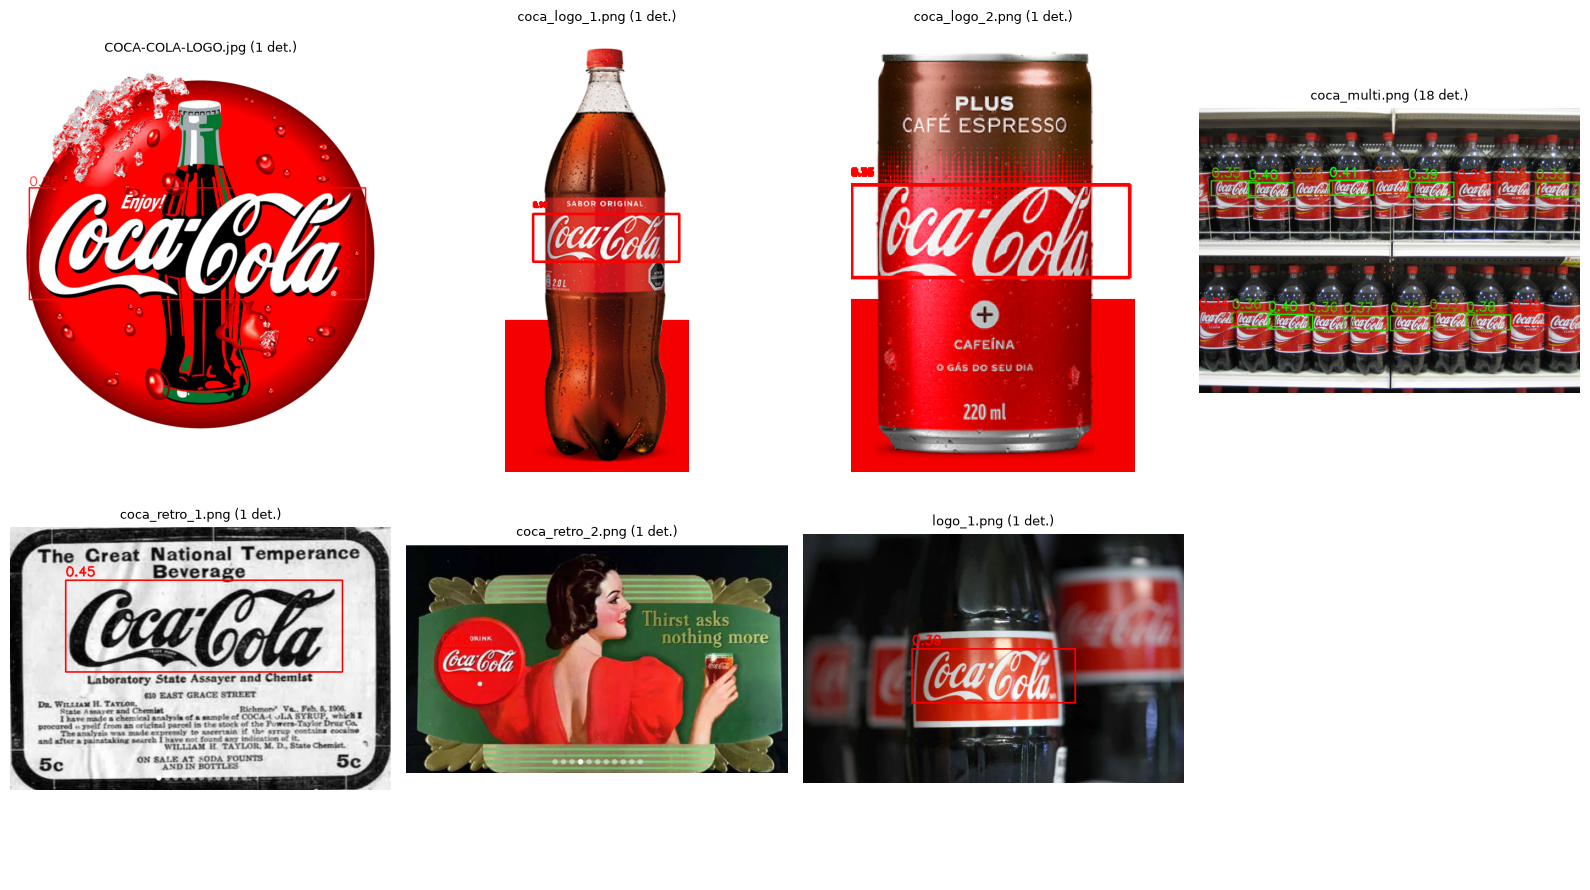

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, filename in zip(axes.flat, image_filenames):
    image_bgr: np.ndarray = read_image(IMAGES_DIR / filename)
    detections: list[Detection] = detect_multiple(template, image_bgr)
    output: np.ndarray = draw_detections(image_bgr, detections)
    ax.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
    ax.set_title(f'{filename} ({len(detections)} det.)', fontsize=9)
    ax.axis('off')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

### Análisis

El mismo algoritmo (matching multiescala sobre bordes + umbral adaptivo + NMS) sirve tanto para detección única como múltiple: el ítem 1 es, en el fondo, el caso particular de quedarse solo con el score máximo. Usar bordes en vez de color/intensidad es lo que permite que funcione tanto en fotos con el logo en blanco sobre rojo (botellas, latas) como en el cartel viejo en blanco y negro. La principal limitación es la calidad del template: en imágenes donde el logo es muy chico, borroso o de bajo contraste (`coca_logo_2.png`), el score máximo baja bastante y el umbral adaptivo queda más cerca del límite, dejando menos margen para detecciones múltiples genuinas — y, como se vio en `logo_1.png`, también más margen para que un pico espurio se cuele si el piso `ratio` está muy bajo.